## Import libraries

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import zscore, skew
import seaborn as sns
import matplotlib.pyplot as plt

## Load data 

In [ ]:
df = pd.read_csv("../data/ethiopia.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


## Convert the YEAR to datetime and add a Country column

In [ ]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

df["Month"] = df["Date"].dt.month

df["Country"] = "Kenya"

# check the data
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,2015-01-01,1,Kenya
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,2015-01-02,1,Kenya
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,2015-01-03,1,Kenya
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,2015-01-04,1,Kenya
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,2015-01-05,1,Kenya


## Summary Statistics & Missing-Value Report

In [5]:
# Replace all occurrences of -999 with np.nan
df.replace(-999, np.nan, inplace=True)

# Duplicates
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

# Summary statistics
df.describe()

Duplicate rows: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


### Interpretation

**Data period:** 4,108 daily records from 2015 to 2026 (about 11–12 years, including leap years).

**Temperature:** Averages 16.1°C (10.0–21.5°C) — mild, with roughly 11.5°C of seasonal spread. Daytime highs average 23.2°C (peak 30.9°C), nighttime lows average 10.2°C (lowest 1.2°C, never freezing). The mean diurnal range is 13.0°C, with some days swinging up to 23°C. No extreme heat or frost; likely temperate or subtropical.

**Rainfall:** Mean is 3.6 mm/day, but the median of 0.8 mm and 75th percentile of 4.6 mm show most days are dry. The maximum reaches 82.3 mm, indicating rare but intense storms — a semi-arid to sub-humid climate.

**Humidity:** Mean RH is 68% (range 14–92%) — generally humid but can get very dry. Mean specific humidity is 9.7 g/kg, moderate moisture typical of mid-latitude or coastal areas.

**Wind:** Average wind speed is 2.0 m/s (max 4.1 m/s) — light breezes. Daily gusts average 3.6 m/s, peaking at 7.5 m/s. Wind is not a dominant feature.

**Pressure:** Mean pressure is 77.0 kPa, far below sea-level standard, indicating moderate to high elevation (~2,000–2,500 m).

**Summary:** Temperate or subtropical highland climate. Mild, no frost, rare heat above 31°C. Mostly dry with occasional heavy rain. Moderate but variable humidity. Light winds. Elevated terrain.

## Percentage of missing values per column

In [ ]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


> No missing values 

## Outlier Detection & Basic Cleaning

In [6]:
# Select numeric columns for outlier detection
numeric_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

# Compute Z-scores (ignoring NaN values)
z_vals = zscore(df[numeric_cols], nan_policy='omit')

# Create a boolean mask for outliers (|Z| > 3)
outlier_mask = (z_vals > 3) | (z_vals < -3)

# Count outliers per column
for i, col in enumerate(numeric_cols):
    col_outlier_count = outlier_mask[:, i].sum()
    print(f"{col}: {col_outlier_count} outliers")

# Flag rows containing any outlier
df["outlier_flag"] = outlier_mask.any(axis=1)
total_outlier_rows = df["outlier_flag"].sum()
print(f"\nTotal rows with at least one outlier: {total_outlier_rows}")

T2M: 3 outliers
T2M_MAX: 0 outliers
T2M_MIN: 18 outliers
PRECTOTCORR: 95 outliers
RH2M: 13 outliers
WS2M: 3 outliers
WS2M_MAX: 5 outliers

Total rows with at least one outlier: 132


**Outlier handling decision:**
For temperature variables (T2M, T2M_MAX, T2M_MIN) and RH2M, I will retain outliers because these values are climatically possible (e.g., natural heatwaves or dry days). For WS2M and WS2M_MAX, I will also retain them as wind gusts can be legitimate. For PRECTOTCORR, extreme values (|Z|>3) likely represent real heavy rainfall events, so I will retain all outliers. No capping or dropping is necessary unless further analysis requires normality.

## Export the cleaned DataFrame

In [ ]:
df.to_csv(f"../data/ethiopia_clean.csv", index=False)

## Time Series Analysis

C:\Users\hp\AppData\Local\Temp\ipykernel_1648\1100436767.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.set_index('Date').resample('M')['T2M'].mean().reset_index()


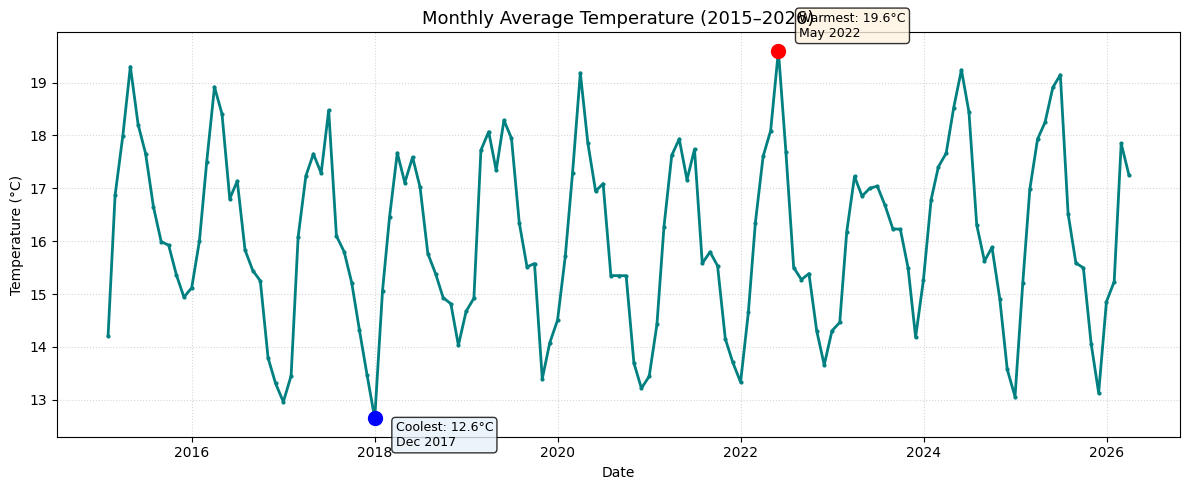

In [7]:
# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create monthly averages
df_monthly = df.set_index('Date').resample('M')['T2M'].mean().reset_index()

# Identify warmest and coolest months
warmest = df_monthly.loc[df_monthly['T2M'].idxmax()]
coolest = df_monthly.loc[df_monthly['T2M'].idxmin()]

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_monthly['Date'], df_monthly['T2M'], color='teal', linewidth=2, marker='.', markersize=4)

# Annotate warmest month
ax.plot(warmest['Date'], warmest['T2M'], 'ro', markersize=10)
ax.annotate(f"Warmest: {warmest['T2M']:.1f}°C\n{warmest['Date'].strftime('%b %Y')}",
            xy=(warmest['Date'], warmest['T2M']), xytext=(15, 10),
            textcoords='offset points', fontsize=9, ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3e0', alpha=0.8))

# Annotate coolest month
ax.plot(coolest['Date'], coolest['T2M'], 'bo', markersize=10)
ax.annotate(f"Coolest: {coolest['T2M']:.1f}°C\n{coolest['Date'].strftime('%b %Y')}",
            xy=(coolest['Date'], coolest['T2M']), xytext=(15, -20),
            textcoords='offset points', fontsize=9, ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#e6f0fa', alpha=0.8))

# Labels and title
ax.set_title('Monthly Average Temperature (2015–2026)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

### Monthly average **T2M** (2015–2026)

**What the chart shows:**  
The line plot reveals a clear seasonal pattern in temperature. The temperature oscillates between **~12°C and ~17-19°C** in a clear pattern
 
Two points are highlighted: the month with the highest average T2M and the month with the lowest average T2M over the entire dataset. These correspond to the peak of the warm season and the peak of the cool season, respectively, for this location between 2015 and 2026.


C:\Users\hp\AppData\Local\Temp\ipykernel_1648\2406114872.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rain = df.resample('M', on='Date')['PRECTOTCORR'].sum().reset_index()


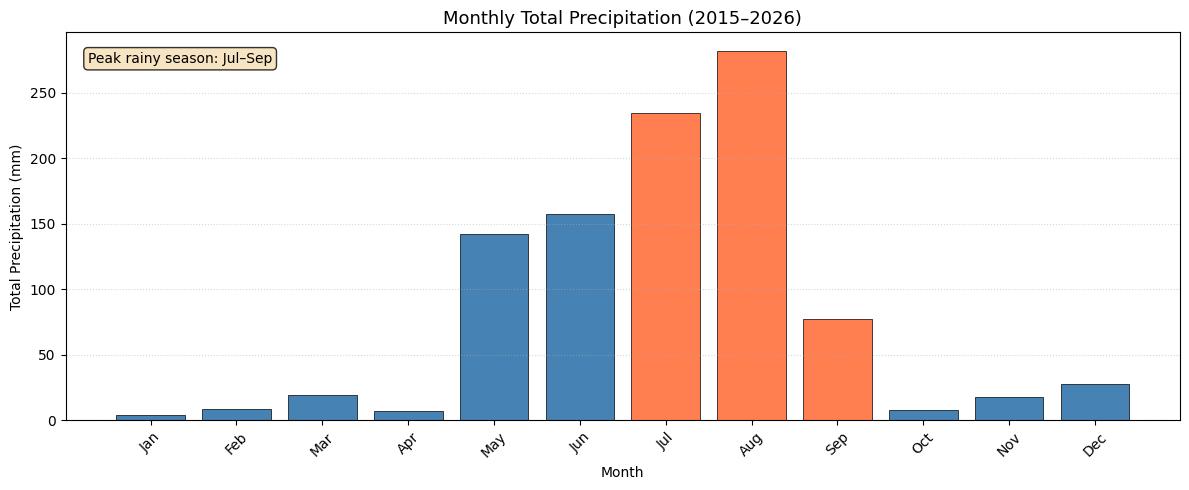

In [8]:
# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Calculate monthly total precipitation
monthly_rain = df.resample('M', on='Date')['PRECTOTCORR'].sum().reset_index()
monthly_rain['Month'] = monthly_rain['Date'].dt.month
monthly_rain['Month_Name'] = monthly_rain['Date'].dt.strftime('%b')

# Find peak rainy season (3 consecutive months with highest total)
monthly_sums = monthly_rain.groupby('Month')['PRECTOTCORR'].sum()

best_total = 0
peak_months = [12, 1, 2]  # default

for start in range(1, 13):
    # Build 3-month window with wrapping (1-12 only)
    three_months = []
    for offset in range(3):
        m = start + offset
        if m > 12:
            m = m - 12
        three_months.append(m)
    
    total = sum(monthly_sums[m] for m in three_months)
    if total > best_total:
        best_total = total
        peak_months = three_months

# Create color mapping: highlight peak season months
monthly_rain['color'] = monthly_rain['Month'].apply(
    lambda m: 'coral' if m in peak_months else 'steelblue'
)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

for month_name in monthly_rain['Month_Name'].unique():
    subset = monthly_rain[monthly_rain['Month_Name'] == month_name]
    color = subset['color'].iloc[0]
    ax.bar(month_name, subset['PRECTOTCORR'].iloc[0], color=color, edgecolor='black', linewidth=0.5)

# Annotate peak season
peak_month_names = [monthly_rain[monthly_rain['Month'] == m]['Month_Name'].iloc[0] for m in peak_months]

if peak_months[0] > peak_months[1]:  # wrapped case (e.g., Dec, Jan, Feb)
    peak_label = f"Peak rainy season: {', '.join(peak_month_names)}"
else:
    peak_label = f"Peak rainy season: {peak_month_names[0]}–{peak_month_names[-1]}"

ax.text(0.02, 0.95, peak_label, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_title('Monthly Total Precipitation (2015–2026)', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Total Precipitation (mm)')
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Monthly total **PRECTOTCORR**

**What the chart shows:**  
Rainfall is unevenly distributed across the year, with a clear seasonal pattern. A small number of months receive the vast majority of precipitation, while many months are relatively dry.
- The three months with the highest total rainfall are labeled directly on the bar chart.
- These represent the most likely periods for peak rainy season activity within this dataset.

## Correlation & Relationship Analysis

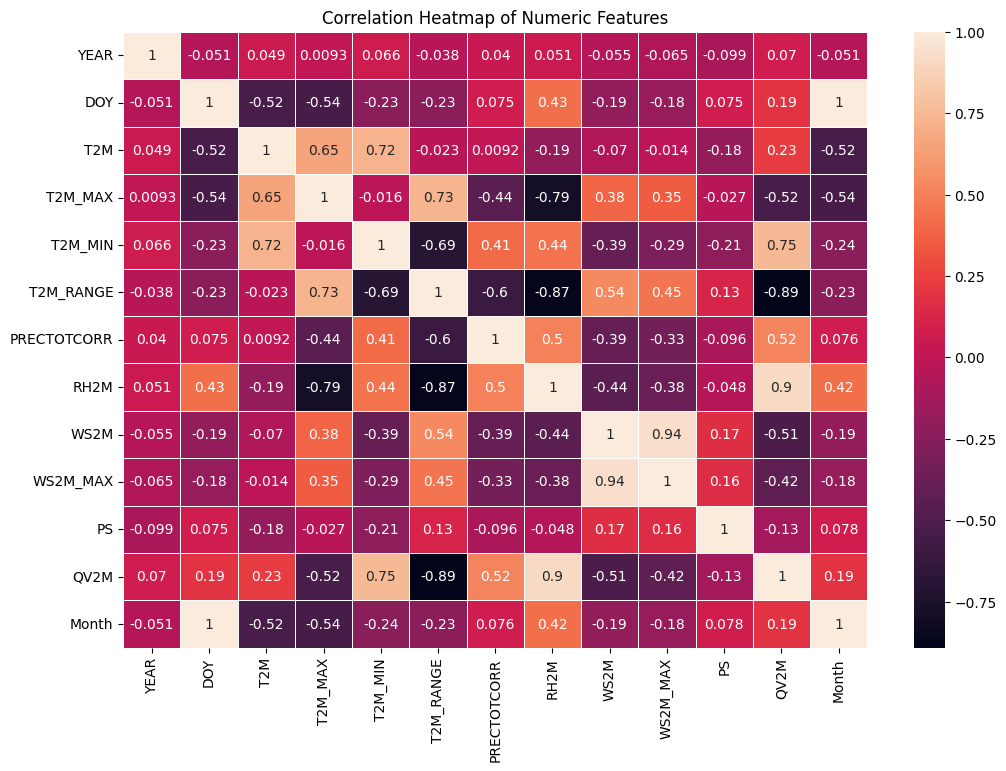

In [9]:
numeric_df = df.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()

# plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True, 
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Features")
plt.show()

### Correlation Analysis

### 1. **WS2M vs WS2M_MAX** (r = 0.941)
Mean daily wind speed and maximum daily wind speed are strongly coupled. Days with higher average winds consistently experience higher speeds. 

### 2. **RH2M vs QV2M** (r = 0.905)
Relative humidity and specific humidity show strong positive correlation. As actual water vapor content (QV2M) increases, relative humidity rises. 

### 3. **T2M_RANGE vs QV2M** (r = -0.892)
Larger daily temperature ranges are strongly associated with **lower** specific humidity (negative correlation).

### T2M vs RH2M 

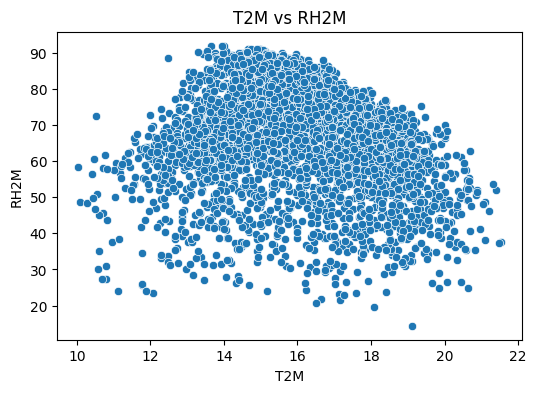

In [10]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.title("T2M vs RH2M")
plt.show()

### T2M vs RH2M

Shows **Negative relationship**. Warmer temperatures are almost always dry. The triangular shape shows that while cool days can be either humid or dry, **warm days are consistently dry** – an important factor for heat stress and crop water demand.

### T2M_RANGE vs WS2M

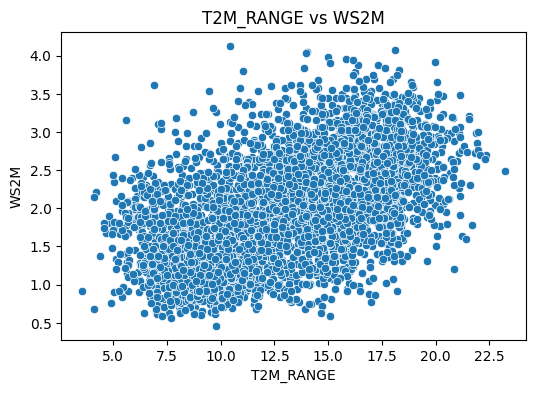

In [11]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")
plt.title("T2M_RANGE vs WS2M")
plt.show()

### T2M_RANGE vs WS2M 

Shows **Strong positive linear relationship**. Larger diurnal temperature swings occur on windier days. This makes physical sense: wind enhances atmospheric mixing and prevents nighttime inversions, allowing both stronger daytime heating and greater nighttime cooling.

## Distribution Analysis

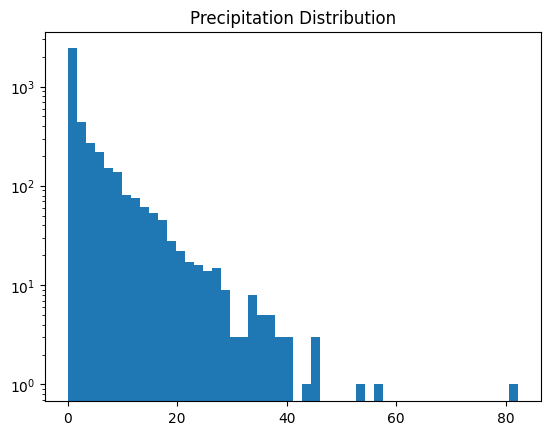

In [ ]:
plt.figure()
plt.hist(df["PRECTOTCORR"].dropna(), bins=50)
plt.yscale("log") 
plt.title("Precipitation Distribution")
plt.show()

### Precipitation Distribution Histogram Interpretation (Log Scale)

It has **Highly right-skewed distribution** where most days experience little to no rainfall. The log-scaled precipitation histogram highlights a climate where dry conditions dominate. It suggests a pattern of frequent light rainfall combined with occasional heavy downpours, illustrating the common “drought and flood” contrast seen in semi-arid to sub-humid environments.

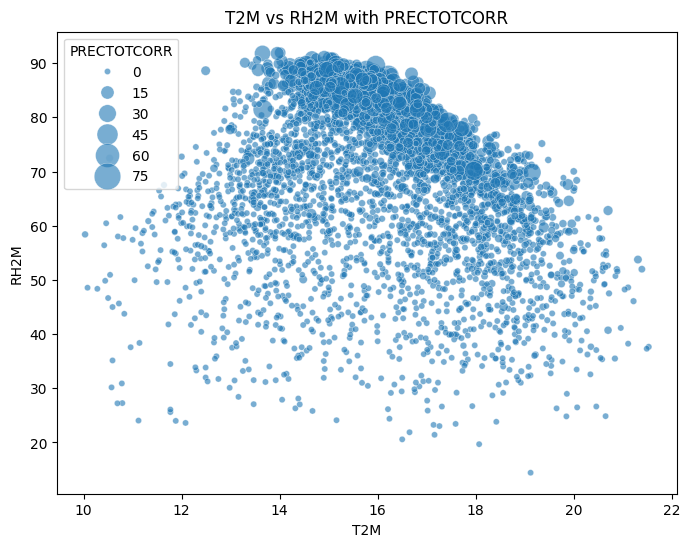

In [12]:
## bubble chart
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="T2M",
    y="RH2M",
    size="PRECTOTCORR",
    sizes=(20, 400),
    alpha=0.6,
    legend=True
)

plt.title("T2M vs RH2M with PRECTOTCORR")
plt.show()

### T2M vs RH2M with PRECTOTCORR

* The biggest bubbles (indicating the heaviest rainfall) are mostly concentrated in areas with **high relative humidity**, and they do not typically align with the highest temperature values. Overall, the chart clearly illustrates that **significant precipitation is linked to moist atmospheric conditions**, while extremely hot days are not usually associated with the greatest rainfall amounts.
